# 02: SVM Training & Feature Analysis
Notebook này tập trung vào việc trích xuất đặc trưng HOG và huấn luyện mô hình SVM để nhận diện trạng thái bãi đỗ xe.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Tách biệt hoàn toàn khỏi backend

def apply_preprocessing(image):
    # Kỹ thuật Chương 2: Tiền xử lý ảnh
    resized = cv2.resize(image, (64, 128))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(gray)
    blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
    return blurred


def get_hog_descriptor():
    # Kỹ thuật Chương 3: Trích xuất đặc trưng hình học
    winSize = (64, 128)
    blockSize = (16, 16)
    blockStride = (8, 8)
    cellSize = (8, 8)
    nbins = 9
    return cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)


### 1. Trực quan hóa HOG Features
HOG (Histogram of Oriented Gradients) giúp bắt được các cạnh và cấu trúc của xe hơi.

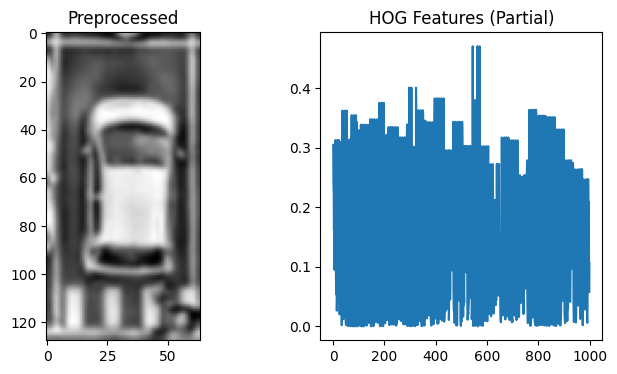

In [2]:
def visualize_hog(img_path):
    if not os.path.exists(img_path):
        return
    
    img = cv2.imread(img_path)
    preprocessed = apply_preprocessing(img)
    
    hog = get_hog_descriptor()
    # compute() trả về vector đặc trưng
    features = hog.compute(preprocessed)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(preprocessed, cmap='gray')
    plt.title("Preprocessed")
    
    plt.subplot(1, 2, 2)
    plt.plot(features[:1000]) # Vẽ 1000 phần tử đầu tiên để quan sát
    plt.title("HOG Features (Partial)")
    plt.show()

# Thử nghiệm với một ảnh bất kỳ trong tập train
sample_path = glob.glob('../backend/data/train/occupied/*.jpg')
if sample_path:
    visualize_hog(sample_path[0])
else:
    print("⚠️ Không tìm thấy ảnh trong data/train/occupied/")

### 2. Huấn luyện SVM
Chúng ta sẽ sử dụng logic từ `backend/core_cv/train_svm.py` nhưng có thêm phần đánh giá.

Dataset loaded: 192 samples.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.96      1.00      0.98        25

    accuracy                           0.97        39
   macro avg       0.98      0.96      0.97        39
weighted avg       0.98      0.97      0.97        39



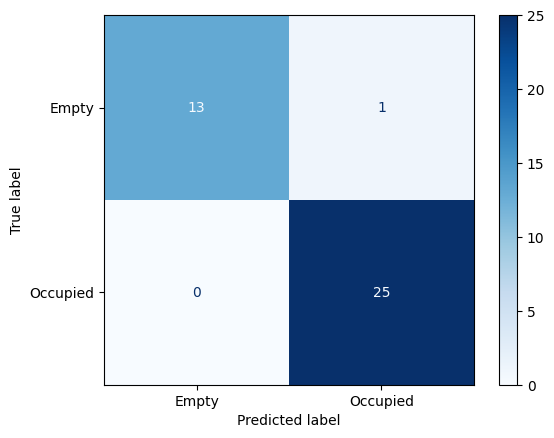

✅ Đã lưu mô hình thành công!


In [3]:
def load_dataset():
    hog = get_hog_descriptor()
    occ_paths = glob.glob('../backend/data/train/occupied/*.jpg')
    emp_paths = glob.glob('../backend/data/train/empty/*.jpg')
    
    features = []
    labels = []
    
    # Hàm nhỏ để đọc và trích xuất
    def process_list(paths, label):
        for p in paths:
            img = cv2.imread(p)
            if img is not None:
                f = hog.compute(apply_preprocessing(img))
                features.append(f.flatten())
                labels.append(label)
    
    process_list(occ_paths, 1)
    process_list(emp_paths, 0)
    
    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int32)

X, y = load_dataset()
print(f"Dataset loaded: {len(X)} samples.")

if len(X) > 0:
    # Chia train/test để đánh giá
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Huấn luyện OpenCV SVM
    svm = cv2.ml.SVM_create()
    svm.setKernel(cv2.ml.SVM_LINEAR)
    svm.setType(cv2.ml.SVM_C_SVC)
    svm.train(X_train, cv2.ml.ROW_SAMPLE, y_train)
    
    # Dự đoán trên tập test
    _, y_pred = svm.predict(X_test)
    
    # In báo cáo
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Ma trận nhầm lẫn (Dùng ConfusionMatrixDisplay thay cho seaborn)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Empty', 'Occupied'])
    disp.plot(cmap='Blues')
    plt.show()
    
    # Lưu mô hình
    MODELS_DIR = '../backend/models'
    os.makedirs(MODELS_DIR, exist_ok=True)
    svm.save(os.path.join(MODELS_DIR, 'svm_parking_model.xml'))
    print("✅ Đã lưu mô hình thành công!")